<a href="https://colab.research.google.com/github/jesusvillota/DataScience_CemfiMaster/blob/main/Session3/3_2_LLM_Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="max-width: 880px; margin: 20px auto 22px; padding: 0px; border-radius: 18px; border: 1px solid #e5e7eb; background: linear-gradient(180deg, #ffffff 0%, #f9fafb 100%); box-shadow: 0 8px 26px rgba(0,0,0,0.06); overflow: hidden;">

  <!-- Banner Header -->
  <div style="padding: 34px 32px 14px; text-align: center; line-height: 1.38;">
    <div style="font-size: 13px; letter-spacing: 0.14em; text-transform: uppercase; color: #6b7280; font-weight: bold; margin-bottom: 5px;">
      Session #3 • Part 2
    </div>
    <div style="font-size: 29px; font-weight: 800; color: #14276c; margin-bottom: 4px;">
      Fine-Tuning Large Language Models
    </div>
    <div style="font-size: 16.5px; color: #374151; font-style: italic; margin-bottom: 0;">
      Data Science for Economics
    </div>
  </div>

  <!-- Logo Section -->
  <div style="background: none; text-align: center; margin: 30px 0 10px;">
    <img src="https://www.cemfi.es/images/Logo-Azul.png" alt="CEMFI Logo" style="width: 158px; filter: drop-shadow(0 2px 12px rgba(56,84,156,0.05)); margin-bottom: 0;">
  </div>

  <!-- Name -->
  <div style="font-family: 'Times New Roman', Times, serif; color: #38549c; text-align: center; font-size: 1.22em; font-weight: bold; margin-bottom: 0px;">
    Jesus Villota Miranda © 2025
  </div>

  <!-- Contact info -->
  <div style="font-family: 'Times New Roman', Times, serif; color: #38549c; text-align: center; font-size: 1em; margin-top: 7px; margin-bottom: 20px;">
    <a href="mailto:jesus.villota@cemfi.edu.es" style="color: #38549c; text-decoration: none; margin-right:8px;" title="Email">
      jesus.villota@cemfi.edu.es
    </a>
    <span style="color:#9fa7bd;">|</span>
    <a href="https://www.linkedin.com/in/jesusvillotamiranda/" target="_blank" style="color: #38549c; text-decoration: none; margin-left:7px;" title="LinkedIn">
      LinkedIn
    </a>
  </div>
</div>


:::
Sources:
- Online courses: [HuggingFace Course](https://huggingface.co/learn/nlp-course)
- Papers: LoRA (Hu et al., 2021), BERT (Devlin et al., 2018)
- Own contributions and adaptations.
:::

---

**IMPORTANT**: **Are you running this notebook in Google Colab?**

- If so, please make sure that in the cell below `running_in_colab` is set to `True`

- And, of course, make sure to **run the cell**!


In [46]:
# ARE YOU RUNNING THIS IN GOOGLE COLAB? If YES, type True below
running_in_colab = False

In [47]:
from pathlib import Path

if running_in_colab: 
    # Install the libraries needed for this notebook
    ! pip install transformers datasets accelerate peft torch scikit-learn pandas tf-keras
    # Set the working folder
    from google.colab import drive
    drive.mount('/content/gdrive')
    folder_dir = Path('/content/gdrive/My Drive/output/3_2')
else: 
    # Install the libraries needed for this notebook
    ! uv add transformers datasets accelerate peft torch tf-keras
    # Set the working folder
    folder_dir = Path('../output/3_2')

# Create the working folder
folder_dir.mkdir(parents=True, exist_ok=True)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Resolved 176 packages in 17ms
Audited 155 packages in 29ms


---


# **Introduction to LLM Fine-Tuning**


Large Language Models (LLMs) like BERT, GPT, and their variants have revolutionized natural language processing by learning rich representations of text through pre-training on massive datasets. However, these models are typically trained on general-purpose corpora and may not be optimal for domain-specific tasks.

**Fine-tuning** is the process of adapting a pre-trained language model to a specific task or domain by continuing training on task-specific data. Instead of training a model from scratch (which is computationally expensive and requires enormous amounts of data), we leverage the knowledge already encoded in the pre-trained model and adjust it for our particular use case.


### **Why Fine-Tune LLMs?**

There are several compelling reasons to fine-tune pre-trained language models:

1. **Domain-Specific Performance**: Pre-trained models may lack knowledge of specialized terminology, concepts, or writing styles in fields like economics, finance, or law.

2. **Task Optimization**: Fine-tuning allows us to optimize models for specific tasks (classification, question-answering, summarization) that may differ from the original pre-training objectives.

3. **Data Efficiency**: Fine-tuning requires significantly less data than training from scratch, making it accessible for applications with limited domain-specific datasets.

4. **Computational Efficiency**: Leveraging pre-trained models reduces the computational resources and time required compared to training large models from scratch.


### **Parameter-Efficient Fine-Tuning (PEFT) and LoRA**

Traditional fine-tuning updates all parameters of the model, which can be:
- **Computationally expensive**: Requires updating millions or billions of parameters
- **Memory intensive**: Needs substantial GPU memory
- **Inefficient**: Most parameters may not need significant changes for task adaptation

**Parameter-Efficient Fine-Tuning (PEFT)** addresses these limitations by updating only a small subset of parameters while freezing most of the pre-trained model.

**LoRA (Low-Rank Adaptation)** is a popular PEFT technique that:
- Adds trainable low-rank matrices to specific layers (typically attention layers)
- Freezes the original model weights
- Requires training only a fraction of the original parameters (often less than 1%)
- Maintains or even improves performance while dramatically reducing computational costs

<!-- <div style="text-align: center; margin: 20px 0;">
    <img src="https://i.imgur.com/j8ONW8r.png" alt="LoRA Architecture" width="500"/>
    <br>
    <em>Diagram: LoRA adds trainable low-rank matrices A and B to frozen weights W</em>
</div> -->


### **Applications in Economics and Finance**

Fine-tuned LLMs have numerous applications in economic research and finance:

- **Sentiment Analysis**: Analyze market sentiment from news articles or social media
- **Policy Analysis**: Classify central bank speeches by topic or policy stance
- **Document Categorization**: Automatically categorize economic reports, research papers, or regulatory filings
- **Entity Extraction**: Extract financial entities, dates, and key economic indicators
- **Summarization**: Generate concise summaries of lengthy economic reports

In this notebook, we'll demonstrate fine-tuning by building a classifier to predict the speaker of European Central Bank (ECB) speeches based on their content.


# **Dataset Preparation**


We'll work with a dataset of European Central Bank (ECB) speeches collected from 2020 onwards. This dataset contains speeches from various ECB officials, providing a rich text corpus for fine-tuning a speaker classification model.

Let's start by loading and exploring the dataset.


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [49]:
# Load the ECB speeches dataset
if running_in_colab:
    data_path = Path('/content/gdrive/My Drive/data/all_ECB_speeches.csv')
else:
    # Adjust this path to match your local file location
    data_path = Path('../data/all_ECB_speeches.csv')

# Load CSV file
df = pd.read_csv(data_path, sep='|', encoding='utf-8')

print(f"✅ Loaded dataset with {len(df):,} speeches")
print(f"\nDataset columns: {list(df.columns)}")
df.head()


✅ Loaded dataset with 2,453 speeches

Dataset columns: ['date', 'speakers', 'title', 'subtitle', 'contents']


,date,speakers,title,subtitle,contents
0,2020-12-17,Isabel Schnabel,Climate change and monetary policy,"Presentation by Isabel Schnabel, Member of the...",NaN
1,2020-12-16,Isabel Schnabel,The importance of trust for the ECB’s monetary...,"Speech by Isabel Schnabel, Member of the Execu...",SPEECH The importance of trust for the ECB’s...
2,2020-12-16,Fabio Panetta,Keeping cyber risk at bay: our individual and ...,"Introductory remarks by Fabio Panetta, Member ...",SPEECH Keeping cyber risk at bay: our indivi...
3,2020-12-15,Philip R. Lane,The resilience of the euro,"Presentation by Philip R. Lane, Member of the ...",NaN
4,2020-12-14,Isabel Schnabel,Welcome address,"Welcome address by Isabel Schnabel, Member of ...",SPEECH Welcome address Welcome address by Is...


In [50]:
# Display basic statistics
print(f"Total number of speeches: {len(df):,}")
print(f"Unique speakers: {df['speakers'].nunique()}")
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")
print(f"\nAverage speech length: {df['contents'].str.len().mean():.0f} characters")
print(f"Median speech length: {df['contents'].str.len().median():.0f} characters")

# Check for missing values
print(f"\nMissing values per column:")
print(df.isnull().sum())

df.dropna(subset=['contents'], inplace=True)

# Check for missing values
print(f"\nMissing values per column after dropping missing values:")
print(df.isnull().sum())


Total number of speeches: 2,453
Unique speakers: 26

Date range: 1997-02-07 to 2020-12-17

Average speech length: 19685 characters
Median speech length: 17620 characters

Missing values per column:
date         0
speakers     0
title        0
subtitle     1
contents    22
dtype: int64

Missing values per column after dropping missing values:
date        0
speakers    0
title       0
subtitle    0
contents    0
dtype: int64


Top 15 speakers by number of speeches:
speakers
Jean-Claude Trichet            329
Benoît Cœuré                   190
Mario Draghi                   186
Yves Mersch                    161
Gertrude Tumpel-Gugerell       158
Willem F. Duisenberg           157
Vítor Constâncio               126
Peter Praet                    126
José Manuel González-Páramo    119
Lorenzo Bini Smaghi            119
Otmar Issing                   100
Jürgen Stark                    88
Lucas Papademos                 87
Sabine Lautenschläger           84
Eugenio Domingo Solans          76
Name: count, dtype: int64


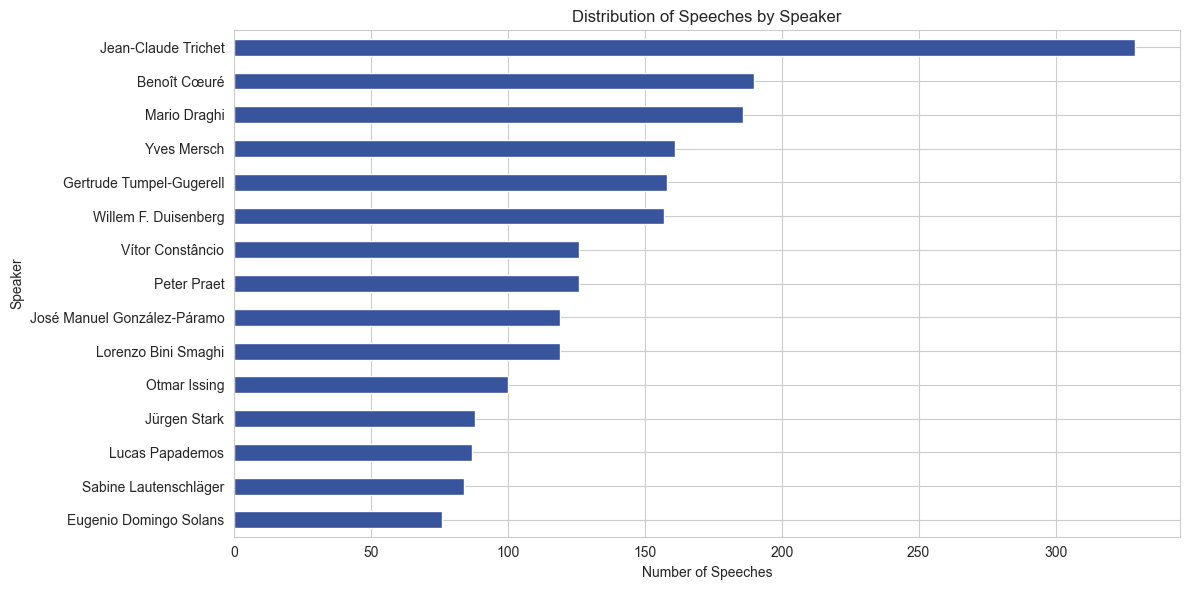

In [51]:
# Count speeches by speaker and identify top speakers
speaker_counts = df['speakers'].value_counts().head(15)
print("Top 15 speakers by number of speeches:")
print(speaker_counts)

# Visualize speaker distribution
plt.figure(figsize=(12, 6))
speaker_counts.plot(kind='barh', color='#38549c')
plt.xlabel('Number of Speeches')
plt.ylabel('Speaker')
plt.title('Distribution of Speeches by Speaker')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### **Creating the Classification Task**

For our fine-tuning task, we'll predict the speaker from the speech content.

First, note that "contents" = [ "title" + "subtitle" + "speech" ]
 - Predicting the label using the "subtitle" is too easy, as the name of the speaker (and other speaker-related characteristics) are being literally mentioned there
 - Let's remove the "subtitle" part from "contents" so that we have no mention to who the speaker is.

In [52]:
# Remove the "subtitle" text from the "contents" column.
# Only perform this if both "subtitle" and "contents" are strings (i.e., not NaN).
def remove_subtitle_from_contents(row):
    subtitle = row['subtitle']
    contents = row['contents']
    if isinstance(subtitle, str) and isinstance(contents, str) and subtitle.strip():
        # Remove the first occurrence of subtitle from contents
        return contents.replace(subtitle, '', 1).strip()
    else:
        # Remove this row
        return None

df_before = df.copy()
df['contents'] = df.apply(remove_subtitle_from_contents, axis=1)
df

,date,speakers,title,subtitle,contents
1,2020-12-16,Isabel Schnabel,The importance of trust for the ECB’s monetary...,"Speech by Isabel Schnabel, Member of the Execu...",SPEECH The importance of trust for the ECB’s m...
2,2020-12-16,Fabio Panetta,Keeping cyber risk at bay: our individual and ...,"Introductory remarks by Fabio Panetta, Member ...",SPEECH Keeping cyber risk at bay: our individu...
4,2020-12-14,Isabel Schnabel,Welcome address,"Welcome address by Isabel Schnabel, Member of ...","SPEECH Welcome address Frankfurt am Main, 14 ..."
5,2020-12-14,Fabio Panetta,A commitment to the recovery,"Speech by Fabio Panetta, Member of the Executi...","SPEECH A commitment to the recovery Rome, 1..."
6,2020-11-27,Fabio Panetta,From the payments revolution to the reinventio...,"Speech by Fabio Panetta, Member of the Executi...",SPEECH From the payments revolution to the re...
...,...,...,...,...,...
2448,1997-05-13,Alexandre Lamfalussy,The European Central Bank: independent and acc...,Keynote speech delivered by Alexandre Lamfalus...,The European Central Bank: independent and acc...
2449,1997-04-30,Alexandre Lamfalussy,The operation of monetary policy in stage thre...,"Address by Alexandre Lamfalussy, President of ...",The operation of monetary policy in stage thre...
2450,1997-04-22,Alexandre Lamfalussy,Convergence and the role of the European Centr...,"Remarks by Alexandre Lamfalussy, President of ...",Convergence and the role of the European Centr...
2451,1997-03-10,Alexandre Lamfalussy,Securing the benefits of EMU,"Address by Alexandre Lamfalussy, President of ...",Securing the benefits of EMU It is a great pl...


Additionally, we remove any other mention to the speaker in the speech

In [53]:
# Remove all mentions of the speaker's name from the "contents" column.
# (Case-insensitive, replaces all occurrences, only if both are strings)
def remove_speaker_mentions(row):
    contents = row['contents']
    speaker = row['speakers']
    if isinstance(contents, str) and isinstance(speaker, str):
        # Remove all occurrences of the speaker's full name (case-insensitive)
        return contents.replace(speaker, '', -1).replace(speaker.lower(), '', -1).replace(speaker.upper(), '', -1).strip()
    else:
        # Remove this row
        return None

df['contents'] = df.apply(remove_speaker_mentions, axis=1)
df

,date,speakers,title,subtitle,contents
1,2020-12-16,Isabel Schnabel,The importance of trust for the ECB’s monetary...,"Speech by Isabel Schnabel, Member of the Execu...",SPEECH The importance of trust for the ECB’s m...
2,2020-12-16,Fabio Panetta,Keeping cyber risk at bay: our individual and ...,"Introductory remarks by Fabio Panetta, Member ...",SPEECH Keeping cyber risk at bay: our individu...
4,2020-12-14,Isabel Schnabel,Welcome address,"Welcome address by Isabel Schnabel, Member of ...","SPEECH Welcome address Frankfurt am Main, 14 ..."
5,2020-12-14,Fabio Panetta,A commitment to the recovery,"Speech by Fabio Panetta, Member of the Executi...","SPEECH A commitment to the recovery Rome, 1..."
6,2020-11-27,Fabio Panetta,From the payments revolution to the reinventio...,"Speech by Fabio Panetta, Member of the Executi...",SPEECH From the payments revolution to the re...
...,...,...,...,...,...
2448,1997-05-13,Alexandre Lamfalussy,The European Central Bank: independent and acc...,Keynote speech delivered by Alexandre Lamfalus...,The European Central Bank: independent and acc...
2449,1997-04-30,Alexandre Lamfalussy,The operation of monetary policy in stage thre...,"Address by Alexandre Lamfalussy, President of ...",The operation of monetary policy in stage thre...
2450,1997-04-22,Alexandre Lamfalussy,Convergence and the role of the European Centr...,"Remarks by Alexandre Lamfalussy, President of ...",Convergence and the role of the European Centr...
2451,1997-03-10,Alexandre Lamfalussy,Securing the benefits of EMU,"Address by Alexandre Lamfalussy, President of ...",Securing the benefits of EMU It is a great pl...


In [54]:
print("\n", "-"*50, "Before:", "-"*50)
before = df_before.iloc[0,4].strip()
display(before)

print("\n", "-"*50, "After:", "-"*50)
after = df.iloc[0,4].strip()
display(after)


 -------------------------------------------------- Before: --------------------------------------------------


"SPEECH The importance of trust for the ECB’s monetary policy Speech by Isabel Schnabel, Member of the Executive Board of the ECB, as part of the seminar series “Havarie Europa. Zur Pathogenese europäischer Gegenwarten” at the Hamburg Institute for Social Research (Hamburger Institut für Sozialforschung) Frankfurt am Main, 16 December 2020 Ladies and gentlemen, Thank you for inviting me to join this seminar series. I am pleased to speak to you today about Europe and about the euro. The seminar series “Havarie Europa”, literally translated as “shipwreck Europe”, touches on a topic that all proponents of European integration are forced to deal with time and again: euro-scepticism. Public trust in the European Union (EU) and European institutions like the European Central Bank (ECB) has suffered considerable strain in recent years due to the global financial crisis, the European sovereign debt crisis and the UK’s withdrawal from the EU. At present, the coronavirus (COVID-19) pandemic is p


 -------------------------------------------------- After: --------------------------------------------------


"SPEECH The importance of trust for the ECB’s monetary policy  Frankfurt am Main, 16 December 2020 Ladies and gentlemen, Thank you for inviting me to join this seminar series. I am pleased to speak to you today about Europe and about the euro. The seminar series “Havarie Europa”, literally translated as “shipwreck Europe”, touches on a topic that all proponents of European integration are forced to deal with time and again: euro-scepticism. Public trust in the European Union (EU) and European institutions like the European Central Bank (ECB) has suffered considerable strain in recent years due to the global financial crisis, the European sovereign debt crisis and the UK’s withdrawal from the EU. At present, the coronavirus (COVID-19) pandemic is posing huge challenges for the European Economic and Monetary Union (EMU). In these stormy conditions, the “ship Europe” has, however, not run aground. European institutions and national governments have responded rapidly and comprehensively to

We'll focus on speakers with sufficient speeches to ensure a balanced dataset. Let's select speakers with at least a certain number of speeches.

In [55]:
# Filter for speakers with at least 10 speeches (adjust as needed)
MIN_SPEECHES = 10

# Get speakers with enough speeches
speaker_filter = df['speakers'].value_counts() >= MIN_SPEECHES
valid_speakers = speaker_filter[speaker_filter].index.tolist()

print(f"Speakers with at least {MIN_SPEECHES} speeches: {len(valid_speakers)}")
print(f"\nSelected speakers:")
for speaker in valid_speakers:
    count = df[df['speakers'] == speaker].shape[0]
    print(f"  - {speaker}: {count} speeches")
    
print(f"\n Ommited speakers:")
for speaker in df['speakers'].unique():
    if speaker not in valid_speakers:
        count = df[df['speakers'] == speaker].shape[0]
        print(f"  - {speaker}: {count} speeches")

# Filter the dataframe
df_filtered = df[df['speakers'].isin(valid_speakers)].copy()

print(f"\n✅ Filtered dataset contains {len(df_filtered):,} speeches")


Speakers with at least 10 speeches: 24

Selected speakers:
  - Jean-Claude Trichet: 329 speeches
  - Benoît Cœuré: 190 speeches
  - Mario Draghi: 186 speeches
  - Yves Mersch: 161 speeches
  - Gertrude Tumpel-Gugerell: 158 speeches
  - Willem F. Duisenberg: 157 speeches
  - Vítor Constâncio: 126 speeches
  - Peter Praet: 126 speeches
  - José Manuel González-Páramo: 119 speeches
  - Lorenzo Bini Smaghi: 119 speeches
  - Otmar Issing: 100 speeches
  - Jürgen Stark: 88 speeches
  - Lucas Papademos: 87 speeches
  - Sabine Lautenschläger: 84 speeches
  - Eugenio Domingo Solans: 76 speeches
  - Jörg Asmussen: 51 speeches
  - Luis de Guindos: 51 speeches
  - Christian Noyer: 51 speeches
  - Tommaso Padoa-Schioppa: 47 speeches
  - Sirkka Hämäläinen: 43 speeches
  - Christine Lagarde: 24 speeches
  - Isabel Schnabel: 18 speeches
  - Philip R. Lane: 18 speeches
  - Fabio Panetta: 14 speeches

 Ommited speakers:
  - Willem F. Duisenberg,Eugenio Domingo Solans: 1 speeches
  - Alexandre Lamfalussy

In [56]:
# Clean and prepare the text data

# Remove very short speeches (likely errors or placeholders)
MIN_LENGTH = 100
df_filtered = df_filtered[df_filtered.loc[:,'contents'].str.len() >= MIN_LENGTH]

# Trim excessive whitespace
df_filtered.loc[:,'contents'] = df_filtered.loc[:,'contents'].str.strip()

print(f"✅ After cleaning: {len(df_filtered):,} speeches")
print(f"📊 Distribution by speaker:")
print(df_filtered.loc[:,'speakers'].value_counts())

✅ After cleaning: 2,419 speeches
📊 Distribution by speaker:
speakers
Jean-Claude Trichet            329
Benoît Cœuré                   188
Mario Draghi                   186
Yves Mersch                    161
Willem F. Duisenberg           157
Gertrude Tumpel-Gugerell       157
Vítor Constâncio               126
Peter Praet                    125
José Manuel González-Páramo    119
Lorenzo Bini Smaghi            119
Otmar Issing                   100
Jürgen Stark                    88
Lucas Papademos                 87
Sabine Lautenschläger           84
Eugenio Domingo Solans          76
Christian Noyer                 51
Jörg Asmussen                   51
Luis de Guindos                 51
Tommaso Padoa-Schioppa          47
Sirkka Hämäläinen               43
Christine Lagarde               24
Philip R. Lane                  18
Isabel Schnabel                 18
Fabio Panetta                   14
Name: count, dtype: int64


In [57]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

# Create speaker label mappings
unique_speakers = sorted(df_filtered.loc[:,'speakers'].unique())
speaker_to_label = {speaker: idx for idx, speaker in enumerate(unique_speakers)}
label_to_speaker = {idx: speaker for speaker, idx in speaker_to_label.items()}

print(f"Speaker labels:")
for speaker, label in speaker_to_label.items():
    print(f"  Label {label}: {speaker}")

# Add label column
df_filtered.loc[:,'label'] = df_filtered.loc[:,'speakers'].map(speaker_to_label)

# Verify label distribution
print(f"\nLabel distribution:")
print(df_filtered.loc[:,'label'].value_counts().sort_index())


Speaker labels:
  Label 0: Benoît Cœuré
  Label 1: Christian Noyer
  Label 2: Christine Lagarde
  Label 3: Eugenio Domingo Solans
  Label 4: Fabio Panetta
  Label 5: Gertrude Tumpel-Gugerell
  Label 6: Isabel Schnabel
  Label 7: Jean-Claude Trichet
  Label 8: José Manuel González-Páramo
  Label 9: Jörg Asmussen
  Label 10: Jürgen Stark
  Label 11: Lorenzo Bini Smaghi
  Label 12: Lucas Papademos
  Label 13: Luis de Guindos
  Label 14: Mario Draghi
  Label 15: Otmar Issing
  Label 16: Peter Praet
  Label 17: Philip R. Lane
  Label 18: Sabine Lautenschläger
  Label 19: Sirkka Hämäläinen
  Label 20: Tommaso Padoa-Schioppa
  Label 21: Vítor Constâncio
  Label 22: Willem F. Duisenberg
  Label 23: Yves Mersch

Label distribution:
label
0     188
1      51
2      24
3      76
4      14
5     157
6      18
7     329
8     119
9      51
10     88
11    119
12     87
13     51
14    186
15    100
16    125
17     18
18     84
19     43
20     47
21    126
22    157
23    161
Name: count, dtype: i

In [58]:
# Split data into train, validation, and test sets
# First, split into [train+val] and [test]
train_val_df, test_df = train_test_split(
    df_filtered, 
    test_size=0.2, 
    random_state=42,
    stratify=df_filtered['label']  # Maintain class distribution
)

# Then split train_val into [train] and [validation]
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    random_state=42,
    stratify=train_val_df['label']
)

del train_val_df

print(f"✅ Data split completed:")
print(f"  Training set: {len(train_df):,} speeches")
print(f"  Validation set: {len(val_df):,} speeches")
print(f"  Test set: {len(test_df):,} speeches")

# Verify class distribution in each split
print(f"\n📊 Class distribution in training set:")
print(train_df['label'].value_counts().sort_index())


✅ Data split completed:
  Training set: 1,548 speeches
  Validation set: 387 speeches
  Test set: 484 speeches

📊 Class distribution in training set:
label
0     120
1      33
2      15
3      49
4       9
5     101
6      11
7     210
8      76
9      33
10     56
11     76
12     56
13     33
14    119
15     64
16     80
17     11
18     54
19     27
20     30
21     81
22    101
23    103
Name: count, dtype: int64


In [59]:
# Convert to HuggingFace datasets format
# Prepare data dictionaries
train_data = {
    'text': train_df['contents'].tolist(),
    'label': train_df['label'].tolist()
}

val_data = {
    'text': val_df['contents'].tolist(),
    'label': val_df['label'].tolist()
}

test_data = {
    'text': test_df['contents'].tolist(),
    'label': test_df['label'].tolist()
}

# Create Dataset objects
dataset = DatasetDict({
    'train': Dataset.from_dict(train_data),
    'validation': Dataset.from_dict(val_data),
    'test': Dataset.from_dict(test_data)
})

print(f"✅ Converted to HuggingFace datasets format")
print(f"\nDataset structure:")
dataset


✅ Converted to HuggingFace datasets format

Dataset structure:


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1548
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 387
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 484
    })
})

# **Model Selection and Tokenization**


### **Why DistilBERT?**

For our text classification task, we'll use **DistilBERT**, a distilled version of BERT that:

- **Is efficient**: 60% faster than BERT while retaining 97% of its performance
- **Excels at classification**: Encoder models like BERT are specifically designed for understanding tasks
- **Requires less memory**: Important for resource-constrained environments
- **Is well-suited for our task**: Speaker identification is fundamentally a classification problem

DistilBERT uses a Transformer-based encoder architecture that processes text bidirectionally, making it excellent for understanding context and identifying subtle linguistic patterns that distinguish different speakers.


In [60]:
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType
import torch

# Check device
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    # Try MPS, but have fallback
    try:
        device = torch.device('mps')
        # Test if MPS works by creating a dummy tensor
        _ = torch.tensor([1]).to(device)
    except:
        device = torch.device('cpu')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)


Using device: mps


### Loading the pre-trained model and tokenizer

In this step, we move from **prepared data** to a **ready-to-train neural model**.

- **`model_name = "distilbert-base-uncased"`**  
  We choose a pre-trained DistilBERT checkpoint from Hugging Face.  
  *`uncased`* means that all text is lowercased during tokenization ("ECB" and "ecb" are treated the same).

- **Tokenizer (`AutoTokenizer`)**  
  `AutoTokenizer.from_pretrained(model_name)` downloads and loads the tokenizer that was used when DistilBERT was originally trained.  
  This tokenizer is responsible for:
  - splitting text into subword tokens,
  - mapping tokens to integer IDs,
  - adding special tokens (like `[CLS]`, `[SEP]`).

- **Classification model (`AutoModelForSequenceClassification`)**  
  `AutoModelForSequenceClassification.from_pretrained(...)` loads the DistilBERT encoder **plus** a randomly initialized classification head on top.
  - `num_labels=len(unique_speakers)` tells the model how many different classes (ECB speakers) we have.
  - `problem_type="single_label_classification"` specifies that **each speech has exactly one speaker**.

Under the hood:
- The DistilBERT layers are loaded with pre-trained weights.
- The final classifier layer is created to output one logit per speaker.

We’ll fine-tune this model so that, given the **contents** of a speech, it learns to predict **which ECB official** most likely gave that speech.

In [61]:
# Load model and tokenizer
model_name = "distilbert-base-uncased"

print(f"📥 Loading model: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(unique_speakers),  # Number of speakers
    problem_type="single_label_classification"
)

print(f"✅ Model loaded successfully")
print(f"📊 Model has {model.num_parameters():,} total parameters")


📥 Loading model: distilbert-base-uncased


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded successfully
📊 Model has 66,971,928 total parameters


### Tokenizing the dataset

Transformer models like DistilBERT **cannot work directly with raw text**. They expect:

- sequences of **token IDs** (integers) instead of words/characters
- plus some extra information like **attention masks** (which tokens are real text vs. padding)

This step converts each speech into the numeric format that the model understands.

#### What `tokenize_function` does

```python
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding=True,
        max_length=512,
        return_tensors='pt'
    )
```

- We pass the **raw text** in `examples['text']` to the Hugging Face `tokenizer`.
- The tokenizer breaks text into **subword tokens** (e.g. `"monetary" → ["mone", "##tary"]`) and maps them to integer IDs.

Key arguments:

- **`truncation=True`**  
  Some speeches are very long. DistilBERT has a **maximum length of 512 tokens**.  
  - If a speech is longer than 512 tokens, the extra part is **cut off** (we keep only the first 512 tokens).

- **`padding=True`**  
  Batches need to be rectangular: all sequences in a batch must have the **same length**.  
  - Shorter speeches are **padded** with special padding tokens so that all sequences in a batch have length 512 (or the max length in that batch).

- **`max_length=512`**  
  Explicitly sets the maximum length of each sequence. This matches DistilBERT’s limit.

- **`return_tensors='pt'`**  
  Returns PyTorch tensors, which is the format expected by our model and Trainer.

The output contains (among others):

- `input_ids`: the token IDs
- `attention_mask`: 1 for real tokens, 0 for padding

#### Applying tokenization to the whole dataset

```python
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text']
)
```

- **`dataset.map(...)`** applies `tokenize_function` to **every example** in the dataset.
- **`batched=True`** means that the function receives a **batch of examples at once** (lists of texts), which is more efficient than one-by-one processing.
- **`remove_columns=['text']`** drops the original raw text column after tokenization, keeping only the fields needed by the model (token IDs, attention masks, labels).

In [62]:
# Tokenize the dataset
def tokenize_function(examples):
    """Tokenize text and return model inputs"""
    return tokenizer(
        examples['text'],
        truncation=True,
        padding=True,
        max_length=512,  # DistilBERT's max sequence length
        return_tensors='pt'
    )

print("🔄 Tokenizing dataset...")
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text']  # Remove original text column after tokenization
)

print("✅ Tokenization complete")
print(f"\nExample tokenized entry:")
print(tokenized_dataset['train'][0])


🔄 Tokenizing dataset...


Map: 100%|██████████| 484/484 [00:01<00:00, 389.81 examples/s]

✅ Tokenization complete

Example tokenized entry:
{'label': 12, 'input_ids': [101, 1996, 6691, 1997, 12194, 3343, 2000, 3171, 3930, 1015, 4955, 1031, 1015, 1033, 1045, 2572, 15936, 2012, 1996, 4495, 2000, 3713, 2012, 2023, 2095, 1005, 1055, 5543, 3034, 7362, 2011, 1996, 1051, 20367, 2890, 11319, 22842, 2120, 9299, 1012, 2023, 2186, 1997, 9281, 2038, 2511, 1037, 2146, 4535, 1011, 2062, 2084, 2382, 2086, 2214, 1011, 1997, 7995, 2006, 3314, 2029, 2024, 2119, 2590, 1998, 25665, 1012, 1996, 4323, 1997, 2023, 2095, 1005, 1055, 3034, 2003, 2053, 6453, 1012, 1000, 6469, 2075, 3171, 3930, 1999, 2885, 1000, 2003, 1996, 3145, 3171, 3343, 9470, 6195, 1996, 8777, 2779, 3930, 1997, 1996, 2647, 4610, 2058, 1996, 2627, 2322, 2086, 1010, 2049, 3522, 5410, 3171, 2836, 1010, 1998, 1996, 3517, 10754, 3171, 7233, 1012, 2000, 6469, 3171, 3930, 1999, 2885, 5942, 2119, 2019, 8321, 11616, 1997, 1996, 5876, 12515, 2030, 9530, 20528, 24002, 2049, 3930, 2836, 1998, 2019, 6413, 3343, 20422, 4953, 1996, 26632, 2303

# **Fine-Tuning with LoRA (Parameter-Efficient Fine-Tuning)**


Now we'll configure LoRA to perform parameter-efficient fine-tuning. This will dramatically reduce the number of trainable parameters while maintaining or improving model performance.


### LoRA configuration

In the next cell we **wrap our DistilBERT model with LoRA adapters**. Instead of updating all ~68M parameters, we freeze the original model and only train a small number of extra parameters added to selected layers.

- **Task type (`task_type=TaskType.SEQ_CLS`)**  
  We tell PEFT/LoRA that this is a **sequence classification** problem: given the full speech text, predict **which ECB speaker** it belongs to.

- **Rank (`r=16`)**  
  LoRA adds a low‑rank update to certain weight matrices. The rank `r` is the **inner dimension** of this low‑rank decomposition:
  
  \(W' = W + B A\) with `A` and `B` having inner size `r`.
  
  A higher `r` → more trainable parameters and capacity; lower `r` → cheaper but less expressive. Here `r=16` is a moderate, efficient choice.

- **Scaling (`lora_alpha=32`)**  
  The LoRA update is scaled by **`alpha / r`** before being added to the frozen weights.  
  With `alpha=32` and `r=16`, the scale is `32 / 16 = 2`, so the LoRA contribution is multiplied by 2. This controls how strong the adapter updates are relative to the base model.

- **Dropout (`lora_dropout=0.1`)**  
  Dropout is applied **only on the LoRA branch**, with probability 0.1 during training. This regularizes the small adapter and helps avoid overfitting to our ECB speeches.

- **Target modules (`target_modules=['q_lin','k_lin','v_lin','out_lin']`)**  
  These are the **attention projection layers** inside DistilBERT where we insert LoRA:
  
  - `q_lin`: query projection
  - `k_lin`: key projection
  - `v_lin`: value projection
  - `out_lin`: output projection of the attention block
  
  Only these layers get extra trainable LoRA matrices; the rest of the model stays frozen.

- **Trainable vs total parameters**  
  After calling `get_peft_model`, we print:
  
  - **Total parameters**: all parameters of DistilBERT + LoRA (~68M)  
  - **Trainable parameters**: only those with `requires_grad=True` (mainly the LoRA adapters, ~1.2M here, i.e. about **1.7%** of the full model)

In [63]:
# Configure LoRA parameters
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # Sequence classification task
    inference_mode=False,
    r=16,  # Rank of decomposition (low-rank dimension)
    lora_alpha=32,  # LoRA scaling parameter
    lora_dropout=0.1,  # Dropout probability for LoRA layers
    target_modules=['q_lin', 'k_lin', 'v_lin', 'out_lin'],  # Which layers to apply LoRA to
)

print("📋 LoRA Configuration:")
print(f"  Task: {lora_config.task_type}")
print(f"  Rank (r): {lora_config.r}")
print(f"  Alpha: {lora_config.lora_alpha}")
print(f"  Dropout: {lora_config.lora_dropout}")
print(f"  Target modules: {lora_config.target_modules}")

# Apply LoRA to the model
model = get_peft_model(model, lora_config)

# Print trainable vs total parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"\n✅ LoRA applied to model")
print(f"📊 Trainable parameters: {trainable_params:,} ({100 * trainable_params / total_params:.2f}%)")
print(f"📊 Total parameters: {total_params:,}")


📋 LoRA Configuration:
  Task: TaskType.SEQ_CLS
  Rank (r): 16
  Alpha: 32
  Dropout: 0.1
  Target modules: {'k_lin', 'v_lin', 'out_lin', 'q_lin'}

✅ LoRA applied to model
📊 Trainable parameters: 1,198,872 (1.76%)
📊 Total parameters: 68,170,800


### Training configuration

In the next cell we tell the **Hugging Face `Trainer`** *how* to train our model: how long, with what learning rate, how often to evaluate, etc. These are the main knobs you would tune in practice.

#### How long and how much data per step

- **`num_train_epochs=3`**  
  One *epoch* means the model sees **all training speeches once**.  
  With `num_train_epochs=3`, the model will go three times through the whole training set, gradually improving its predictions.

- **`per_device_train_batch_size=8`**  
  During training, the model does not see all speeches at once. Instead, it processes them in **mini-batches**.  
  Here, each training step uses **8 speeches at a time** on your device (CPU/GPU). After each batch, the model updates its weights.

- **`per_device_eval_batch_size=8`**  
  Same idea, but for **evaluation**. We also run validation in batches of 8 speeches to measure how well the model is doing, without updating weights.

#### How fast the model learns

- **`learning_rate=2e-4` (0.0002)**  
  Controls **how big each update step** is when the model learns from its mistakes.  
  - If the learning rate is **too large**, training can become unstable and the model might “bounce around” without improving.  
  - If it is **too small**, training becomes very slow.  
  The chosen value is a typical starting point for fine‑tuning transformer models.

- **`weight_decay=0.01`**  
  A form of **regularization** (L2 penalty) that gently pushes weights towards smaller values.  
  Intuition: simpler models (with smaller weights) tend to **generalize better** and overfit less to the training data.

- **`warmup_steps=100`**  
  For the first 100 training steps, the learning rate is **gradually increased from 0 up to 0.0002**.  
  This “warm‑up” avoids making big, aggressive updates at the very beginning, when the model is still badly calibrated for the new task.

#### When to evaluate and what to save

- **`eval_strategy="epoch"`**  
  We run an **evaluation pass on the validation set at the end of each epoch**.  
  This tells us how well the model performs on data it has *not* seen during training.

- **`save_strategy="epoch"`**  
  We **save a checkpoint at the end of each epoch** (model weights + training state).  
  This lets us go back to earlier versions of the model if needed.

- **`load_best_model_at_end=True`**  
  After training finishes, the Trainer automatically **reloads the best checkpoint** according to a chosen metric (below). You end up with the best version, not just the last one.

- **`metric_for_best_model="accuracy"`**  
  We define what “best” means. Here, it is the model with the **highest accuracy on the validation set** (fraction of correctly predicted speakers).

- **`greater_is_better=True`**  
  For accuracy, **higher is better**, so the Trainer keeps the checkpoint with the **maximum** accuracy.

In [64]:
# Configure training arguments
training_args = TrainingArguments(
    output_dir=str(folder_dir / 'results'),
    overwrite_output_dir=True,
    num_train_epochs=3,  # Number of training epochs
    per_device_train_batch_size=8,  # Batch size for training
    per_device_eval_batch_size=8,  # Batch size for evaluation
    learning_rate=2e-4,  # Learning rate
    weight_decay=0.01,  # Weight decay for regularization
    warmup_steps=100,  # Number of warmup steps
    logging_dir=str(folder_dir / 'logs'),
    logging_steps=10,  # Log every N steps
    eval_strategy="epoch",  # Evaluate after each epoch
    save_strategy="epoch",  # Save checkpoint after each epoch
    load_best_model_at_end=True,  # Load best model at end
    metric_for_best_model="accuracy",  # Metric to select best model
    greater_is_better=True,
    push_to_hub=False,  # Set to True if you want to push to HuggingFace Hub
    report_to="none",  # Disable wandb/tensorboard if not needed
)

print("📋 Training Configuration:")
for key, value in training_args.to_dict().items():
    print(f"  {key}: {value}")


📋 Training Configuration:
  output_dir: ../output/3_2/results
  overwrite_output_dir: True
  do_train: False
  do_eval: True
  do_predict: False
  eval_strategy: epoch
  prediction_loss_only: False
  per_device_train_batch_size: 8
  per_device_eval_batch_size: 8
  per_gpu_train_batch_size: None
  per_gpu_eval_batch_size: None
  gradient_accumulation_steps: 1
  eval_accumulation_steps: None
  eval_delay: 0
  torch_empty_cache_steps: None
  learning_rate: 0.0002
  weight_decay: 0.01
  adam_beta1: 0.9
  adam_beta2: 0.999
  adam_epsilon: 1e-08
  max_grad_norm: 1.0
  num_train_epochs: 3
  max_steps: -1
  lr_scheduler_type: linear
  lr_scheduler_kwargs: {}
  warmup_ratio: 0.0
  warmup_steps: 100
  log_level: passive
  log_level_replica: warning
  log_on_each_node: True
  logging_dir: ../output/3_2/logs
  logging_strategy: steps
  logging_first_step: False
  logging_steps: 10
  logging_nan_inf_filter: True
  save_strategy: epoch
  save_steps: 500
  save_total_limit: None
  save_safetensors: T

In [65]:
# Define metrics for evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    """Compute metrics for evaluation"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted'
    )
    accuracy = accuracy_score(labels, predictions)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

# Data collator for dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("✅ Metrics and data collator configured")


✅ Metrics and data collator configured


In [66]:
# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

print("✅ Trainer created and ready for training")


✅ Trainer created and ready for training


### **Training the Model**

Now let's train the model! This will update only the LoRA parameters, keeping the vast majority of the pre-trained weights frozen.


In [67]:
# Train the model
print("🚀 Starting training...")
trainer.train()

print("\n✅ Training complete!")


🚀 Starting training...


/Users/jesusvillotamiranda/Library/CloudStorage/OneDrive-UniversidaddeLaRioja/GitHub/Repository/Teaching/DataScience_CemfiMaster/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.427400,2.250090,0.297158,0.191548,0.297158,0.195436
2,1.815400,1.662094,0.483204,0.457328,0.483204,0.424426
3,1.426700,1.518499,0.503876,0.509383,0.503876,0.461487


/Users/jesusvillotamiranda/Library/CloudStorage/OneDrive-UniversidaddeLaRioja/GitHub/Repository/Teaching/DataScience_CemfiMaster/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jesusvillotamiranda/Library/CloudStorage/OneDrive-UniversidaddeLaRioja/GitHub/Repository/Teaching/DataScience_CemfiMaster/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/jesusvillotamiranda/Library/CloudStorage/OneDrive-UniversidaddeLaRioja/GitHub/Repository/Teaching/DataScience_CemfiMaster/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: Undefine


✅ Training complete!


# **Evaluation and Results**


In [68]:
# Evaluate on validation set
print("📊 Evaluating on validation set...")
val_results = trainer.evaluate()

print("\nValidation Results:")
for metric, value in val_results.items():
    if isinstance(value, float):
        print(f"  {metric}: {value:.4f}")
    else:
        print(f"  {metric}: {value}")


📊 Evaluating on validation set...


/Users/jesusvillotamiranda/Library/CloudStorage/OneDrive-UniversidaddeLaRioja/GitHub/Repository/Teaching/DataScience_CemfiMaster/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



Validation Results:
  eval_loss: 1.5185
  eval_accuracy: 0.5039
  eval_precision: 0.5094
  eval_recall: 0.5039
  eval_f1: 0.4615
  eval_runtime: 9.0041
  eval_samples_per_second: 42.9800
  eval_steps_per_second: 5.4420
  epoch: 3.0000


/Users/jesusvillotamiranda/Library/CloudStorage/OneDrive-UniversidaddeLaRioja/GitHub/Repository/Teaching/DataScience_CemfiMaster/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [69]:
# Evaluate on test set
print("📊 Evaluating on test set...")
test_results = trainer.evaluate(eval_dataset=tokenized_dataset['test'])

print("\nTest Results:")
for metric, value in test_results.items():
    if isinstance(value, float):
        print(f"  {metric}: {value:.4f}")
    else:
        print(f"  {metric}: {value}")


/Users/jesusvillotamiranda/Library/CloudStorage/OneDrive-UniversidaddeLaRioja/GitHub/Repository/Teaching/DataScience_CemfiMaster/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


📊 Evaluating on test set...

Test Results:
  eval_loss: 1.5074
  eval_accuracy: 0.4752
  eval_precision: 0.4565
  eval_recall: 0.4752
  eval_f1: 0.4371
  eval_runtime: 10.9952
  eval_samples_per_second: 44.0190
  eval_steps_per_second: 5.5480
  epoch: 3.0000


/Users/jesusvillotamiranda/Library/CloudStorage/OneDrive-UniversidaddeLaRioja/GitHub/Repository/Teaching/DataScience_CemfiMaster/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


/Users/jesusvillotamiranda/Library/CloudStorage/OneDrive-UniversidaddeLaRioja/GitHub/Repository/Teaching/DataScience_CemfiMaster/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/jesusvillotamiranda/Library/CloudStorage/OneDrive-UniversidaddeLaRioja/GitHub/Repository/Teaching/DataScience_CemfiMaster/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


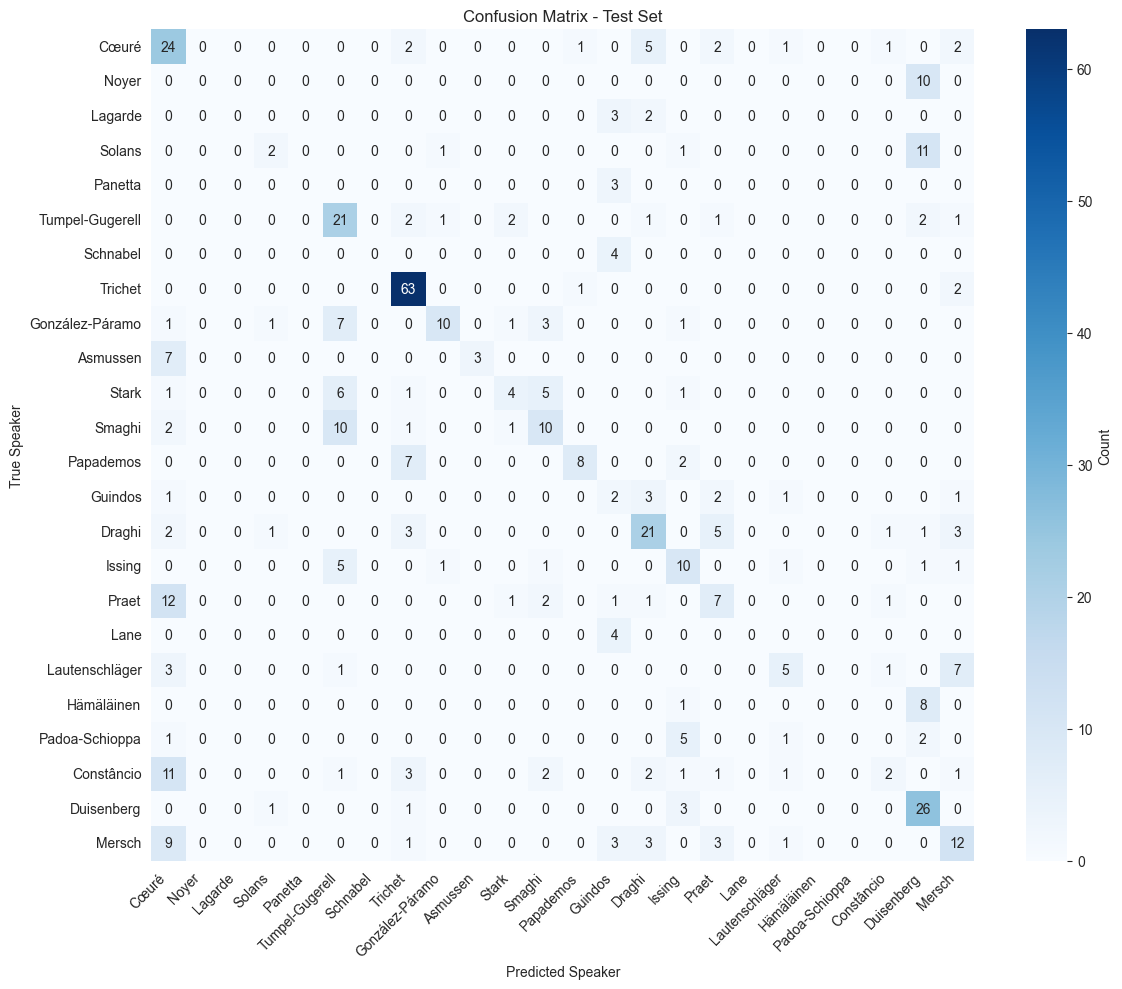

In [70]:
# Get predictions on test set
predictions = trainer.predict(tokenized_dataset['test'])
predicted_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# Create confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=[label_to_speaker[i].split()[-1] for i in range(len(unique_speakers))],  # Use last name for brevity
    yticklabels=[label_to_speaker[i].split()[-1] for i in range(len(unique_speakers))],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Speaker')
plt.ylabel('True Speaker')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [71]:
# Show some example predictions
print("📝 Example Predictions from Test Set:\n")
indices = np.random.choice(len(true_labels), size=10, replace=False)

for idx in indices:
    true_label = true_labels[idx]
    pred_label = predicted_labels[idx]
    correct = "✅" if true_label == pred_label else "❌"
    
    # Get a snippet of the text
    text_snippet = test_df.iloc[idx]['contents'][:200] + "..."
    
    print(f"{correct} Example {idx}:")
    print(f"   True: {label_to_speaker[true_label]}")
    print(f"   Pred: {label_to_speaker[pred_label]}")
    print(f"   Text: {text_snippet}")
    print()


📝 Example Predictions from Test Set:

❌ Example 418:
   True: Yves Mersch
   Pred: Benoît Cœuré
   Text: The causes of monetary policy measures and their impact – a review Speech by , Member of the Executive Board of the ECB,at the Euro Finance Week, FAROS Institutional Investors Forum,Frankfurt, 17 Nove...

❌ Example 474:
   True: Eugenio Domingo Solans
   Pred: Willem F. Duisenberg
   Text: The euro in the international capital markets  Allow me to begin by stating that I am convinced that the euro will play a decisive role in the world economy and in the international capital markets. I...

❌ Example 181:
   True: Lorenzo Bini Smaghi
   Pred: Gertrude Tumpel-Gugerell
   Text: Real convergence in Central, Eastern and South-Eastern Europe Speech by , Member of the Executive Board of the ECB at the ECB Conference on central, eastern and south-eastern Europe,Frankfurt, 1 Octob...

❌ Example 446:
   True: Sirkka Hämäläinen
   Pred: Willem F. Duisenberg
   Text: Integrating Europe's Finan

# **Practical Applications**


In [73]:
# Define inference function
def predict_speaker(text, model, tokenizer, label_to_speaker):
    """
    Predict the speaker from a text snippet
    
    Args:
        text: Input text string
        model: Fine-tuned model
        tokenizer: Tokenizer
        label_to_speaker: Mapping from label to speaker name
    
    Returns:
        Dictionary with predicted speaker and confidence
    """
    # Tokenize input
    inputs = tokenizer(text, truncation=True, padding=True, max_length=512, return_tensors="pt")
    
    # Move to device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Get prediction
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probabilities = torch.nn.functional.softmax(logits, dim=-1)
        predicted_label = torch.argmax(probabilities, dim=-1).item()
        confidence = probabilities[0][predicted_label].item()
    
    return {
        'speaker': label_to_speaker[predicted_label],
        'confidence': confidence,
        'all_probabilities': {
            label_to_speaker[i]: prob.item() 
            for i, prob in enumerate(probabilities[0])
        }
    }

print("✅ Inference function defined")


✅ Inference function defined


In [81]:
# Test on some example speeches
print("🔮 Testing on sample speeches:\n")

# Get some random examples from the test set
test_indices = np.random.choice(len(test_df), size=3, replace=False)

for idx in test_indices:
    text = test_df.iloc[idx]['contents']
    true_speaker = test_df.iloc[idx]['speakers']
    
    # Make prediction
    result = predict_speaker(text, model, tokenizer, label_to_speaker)
    
    # Display results
    print(f"Example {idx}:")
    print(f"  True speaker: {true_speaker}")
    print(f"  Predicted speaker: {result['speaker']}")
    print(f"  Confidence: {result['confidence']:.2%}")
    print(f"  Correct: {'✅' if result['speaker'] == true_speaker else '❌'}")
    print()


🔮 Testing on sample speeches:

Example 301:
  True speaker: Jean-Claude Trichet
  Predicted speaker: Jean-Claude Trichet
  Confidence: 96.39%
  Correct: ✅

Example 478:
  True speaker: Eugenio Domingo Solans
  Predicted speaker: Eugenio Domingo Solans
  Confidence: 59.21%
  Correct: ✅

Example 374:
  True speaker: Gertrude Tumpel-Gugerell
  Predicted speaker: Gertrude Tumpel-Gugerell
  Confidence: 58.18%
  Correct: ✅



In [82]:
# Save the model and tokenizer
model_save_path = folder_dir / 'fine_tuned_model'

print(f"💾 Saving model to {model_save_path}...")
trainer.save_model(str(model_save_path))
tokenizer.save_pretrained(str(model_save_path))

print("✅ Model saved successfully")

# Also save the label mappings
import json

mappings = {
    'speaker_to_label': speaker_to_label,
    'label_to_speaker': {str(k): v for k, v in label_to_speaker.items()}
}

with open(model_save_path / 'label_mappings.json', 'w') as f:
    json.dump(mappings, f, indent=2)

print("✅ Label mappings saved")


💾 Saving model to ../output/3_2/fine_tuned_model...
✅ Model saved successfully
✅ Label mappings saved


### **Loading a Saved Model**

To load the model for future use:

```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel
import torch

# Load base model
model_name = "distilbert-base-uncased"
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(speaker_to_label)
)

# Load LoRA weights
model = PeftModel.from_pretrained(base_model, str(model_save_path))
tokenizer = AutoTokenizer.from_pretrained(str(model_save_path))

# Load label mappings
with open(model_save_path / 'label_mappings.json', 'r') as f:
    mappings = json.load(f)
    label_to_speaker = {int(k): v for k, v in mappings['label_to_speaker'].items()}
```


### **Potential Extensions**

There are many directions you could extend this work:

**1. Different Tasks**
   - **Sentiment Analysis**: Classify speeches by sentiment (hawkish vs. dovish)
   - **Topic Classification**: Categorize speeches by economic topic (monetary policy, financial stability, digital euro, etc.)
   - **Named Entity Recognition**: Extract key entities like dates, institutions, and economic indicators

**2. Model Variants**
   - Try larger models (BERT-base, RoBERTa) for potentially better performance
   - Experiment with different PEFT techniques (Prompt Tuning, AdaLoRA)
   - Compare LoRA performance against full fine-tuning

**3. Advanced Techniques**
   - Implement multi-task learning (joint speaker and topic classification)
   - Use few-shot learning for speakers with limited speeches
   - Apply data augmentation techniques to expand the training set

**4. Deployment**
   - Deploy the model as a web API using FastAPI or Flask
   - Create a Streamlit dashboard for interactive inference
   - Integrate into a larger pipeline for automated speech analysis

**5. Generation Tasks**
   - Fine-tune decoder models (GPT-2, Llama) for speech generation
   - Create summarization models for ECB speeches
   - Build question-answering systems on financial documents


### **Resources for Further Learning**

- **HuggingFace Transformers**: [https://huggingface.co/docs/transformers/](https://huggingface.co/docs/transformers/)
- **PEFT Library**: [https://huggingface.co/docs/peft/](https://huggingface.co/docs/peft/)
- **LoRA Paper**: Low-Rank Adaptation of Large Language Models (Hu et al., 2021)
- **BERT Paper**: Pre-training of Deep Bidirectional Transformers for Language Understanding (Devlin et al., 2018)